In [11]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import joblib
import random
import numpy as np
from scipy.stats import linregress
import torch
from matplotlib import pyplot as plt
from syd import make_viewer, Viewer
from tqdm import tqdm

from vrAnalysis.database import get_database
from vrAnalysis.helpers import Timer, sort_by_preferred_environment, edge2center, cross_validate_trials, get_placefield_location
from vrAnalysis.helpers.plotting import beeswarm, format_spines, insert_nans_at_gaps, save_figure, add_scaled_limits
from vrAnalysis.sessions import B2Session, SpksTypes
from vrAnalysis.processors import SpkmapProcessor
from vrAnalysis.processors.support import median_zscore
from vrAnalysis.processors.placefields import get_placefield, get_frame_behavior, get_placefield_prediction
from dimilibi import measure_r2, mse
from dimilibi.pca import PCA
from dimilibi import gaussian_filter, fit_powerlaw_decay, fit_powerlaw_derivatives
from dimensionality_manuscript.registry import PopulationRegistry, get_model, ModelName, short_model_name
from dimensionality_manuscript.workflows.measure_cvpca import get_filepath as get_cvpca_filepath
from dimensionality_manuscript.workflows.measure_cvpca import nanmax
from dimensionality_manuscript import StimSpaceConfig, get_data_config, ResultsStore, ResultsAggregator
from dimensionality_manuscript.registry import StimSpaceSubspace
from dimensionality_manuscript.regression_models.hyperparameters import PlaceFieldHyperparameters

plt.rcParams["font.size"] = 12

# get session database
sessiondb = get_database("vrSessions")

# get population registry and models
registry = PopulationRegistry()

In [12]:
cfg = StimSpaceConfig()
sessions = sessiondb.iter_sessions(imaging=True)
store = ResultsStore()
results = ResultsAggregator(cfg, store, sessions)

In [14]:
def xvals(x):
    return np.arange(x.shape[1]) + 1

class SubspaceViewer(Viewer):
    def __init__(self, results: ResultsAggregator):
        self = cfg.build_syd(self, results)
        self.update_selection("view_by", value="mouse_average")

        self.add_boolean("include_pfpf", value=False)
        self.add_selection("xscale", options=["log", "linear"], value="log")

        preferred_state = {
            "spks_type": "sigrebase",
            "smooth_width": None,
            "activity_parameters_name": "default",
        }
        for key, value in preferred_state.items():
            self.update_selection(key, value=value)

        # self.add_selection("yscale", options=["log", "linear"], value="log")
        add_scaled_limits(self, max_value=2.0, min_log_exponent=-12, y=True, log_default=True)

        self.update_float_range("ylims", value=(-5.0, -0.5))
        self.add_boolean("use_cv", value=True)
        self.add_boolean("energy_scale", value=True)

    def plot(self, state: dict):
        result, axes_names = self.get_result(state)

        if state["energy_scale"]:
            full = result["variance_activity"] ** 2
            if state["use_cv"]:
                pfs = result["cv_variance_squared_placefields"]
                pfpf = result["cv_variance_squared_placefield_placefield"]
            else:
                pfs = result["variance_placefields"] ** 2
                pfpf = result["variance_placefield_placefield"] ** 2

        else:
            full = result["variance_activity"]
            if state["use_cv"]:
                pfs = np.sqrt(np.maximum(result["cv_variance_squared_placefields"], 0.0))
                pfpf = np.sqrt(np.maximum(result["cv_variance_squared_placefield_placefield"], 0.0))
            else:
                pfs = result["variance_placefields"]
                pfpf = result["variance_placefield_placefield"]
        
        full_total = np.nansum(full, axis=1)

        nfull = full / full_total[:, None]
        npfs = pfs / full_total[:, None]
        npfpf = pfpf / full_total[:, None]

        cfull = np.cumsum(nfull, axis=1)
        cpfs = np.cumsum(npfs, axis=1)
        cpfpf = np.cumsum(npfpf, axis=1)

        full_color = "black"
        placefield_color = "orange"
        pfpf_color = "blue"
        each_alpha = 0.3
        fig, ax = plt.subplots(1, 3, figsize=(9, 4), layout="constrained", width_ratios=[1, 1, 0.5])

        ax[0].plot(xvals(nfull), nfull.T, color=(full_color, each_alpha))
        ax[0].plot(xvals(npfs), npfs.T, color=(placefield_color, each_alpha))
        if state["include_pfpf"]:
            ax[0].plot(xvals(npfpf), npfpf.T, color=(pfpf_color, each_alpha))
        ax[0].plot(xvals(nfull), np.nanmean(nfull, axis=0), color=full_color, label="Full")
        ax[0].plot(xvals(npfs), np.nanmean(npfs, axis=0), color=placefield_color, label="PF")
        if state["include_pfpf"]:
            ax[0].plot(xvals(npfpf), np.nanmean(npfpf, axis=0), color=pfpf_color, label="PF-PF")
        ax[0].legend()
        ax[0].set_xlabel("Dimension")
        ax[0].set_ylabel("Variance")
        ax[0].set_xscale(state["xscale"])
        ax[0].set_yscale(state["yscale"])
        ax[0].set_ylim(self.get_ylims(state))

        ax[1].plot(xvals(cfull), cfull.T, color=(full_color, each_alpha))
        ax[1].plot(xvals(cpfs), cpfs.T, color=(placefield_color, each_alpha))
        if state["include_pfpf"]:
            ax[1].plot(xvals(cpfpf), cpfpf.T, color=(pfpf_color, each_alpha))
        ax[1].plot(xvals(cfull), np.nanmean(cfull, axis=0), color=full_color, label="Full")
        ax[1].plot(xvals(cpfs), np.nanmean(cpfs, axis=0), color=placefield_color, label="PF")
        if state["include_pfpf"]:
            ax[1].plot(xvals(cpfpf), np.nanmean(cpfpf, axis=0), color=pfpf_color, label="PF-PF")
        ax[1].legend()
        ax[1].set_xlabel("Dimension")
        ax[1].set_ylabel("Cumulative Variance")
        ax[1].set_xscale(state["xscale"])
        ax[1].set_yscale(state["yscale"])

        # Also plot ratio of cumulative variance
        full_total = np.nansum(nfull, axis=1)
        pf_total = np.nansum(npfs, axis=1)
        pfpf_total = np.nansum(npfpf, axis=1)

        stack = pf_total.reshape(1, -1)
        
        xticks = [0]
        xticklabels = ["PF SVR"]
        if state["include_pfpf"]:
            stack = np.concatenate([stack, pfpf_total.reshape(1, -1)], axis=0)
            xticks.append(1)
            xticklabels.append("PF-PF")

        ax[2].plot(xticks, 100*stack, color=full_color, linewidth=0.5, marker="o", markersize=3)
        ax[2].set_title(np.round(np.mean(stack[0]) * 100, 3))
        ax[2].set_ylim(0, 100)
        ax[2].set_xlim(-0.5, max(xticks) + 0.5)
        ax[2].set_xticks(xticks, labels=xticklabels, rotation=45, ha="right")
        ax[2].set_xlabel("Subspace")
        ax[2].set_ylabel("Ratio (SVR)")

        return fig

viewer = SubspaceViewer(results)
viewer.show()

C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\pipeline\aggregate.py:44: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(arr[mouse_names == mouse], axis=0)


In [ ]:
class StimspaceFamiliarityViewer(Viewer):
    def __init__(self, results: ResultsAggregator):
        self.results = results
        for key, value in results.param_axes.items():
            self.add_selection(key, options=value)

        self.add_boolean("normalize", value=False)

        preferred_state = {
            "spks_type": "sigrebase",
            "smooth_width": None,
            "activity_parameters_name": "default",
            "centered": True,
        }
        for key, value in preferred_state.items():
            self.update_selection(key, value=value)
        

    def plot(self, state: dict):
        _sel_state = {k: v for k, v in state.items() if k in self.results.param_axes}
        out = self.results.sel(**_sel_state)
        full = out["variance_activity"]
        pfs = np.sqrt(np.maximum(out["cv_variance_squared_placefields"], 0.0))
        pfpf = np.sqrt(np.maximum(out["cv_variance_squared_placefield_placefield"], 0.0))

        full_total = np.nansum(full, axis=1)

        npfs = pfs / full_total[:, None]
        npfpf = pfpf / full_total[:, None] # not used -- if wanted include same way as svr

        pf_total = np.nansum(npfs, axis=1)
        full_total = np.nansum(full, axis=1)

        svr = {}
        total = {}
        num_envs = {}
        unique_mice = self.results.unique_mice
        bad_envs = np.array([-1 in session.environments for session in self.results.sessions], dtype=bool)
        for mouse in unique_mice:
            idx_mouse = self.results.mouse_names == mouse
            idx_to_mouse = np.where(idx_mouse & ~bad_envs)[0]

            # idx_to_mouse = np.where(self.results.mouse_names == mouse)[0]

            dates = np.array([self.results.sessions[idx].date for idx in idx_to_mouse])
            _idx_sorted = np.argsort(dates)
            idx_to_mouse = idx_to_mouse[_idx_sorted]
            num_envs[mouse] = np.array([len(self.results.sessions[idx].environments) for idx in idx_to_mouse])
            svr[mouse] = pf_total[idx_to_mouse]
            total[mouse] = full_total[idx_to_mouse]

            if state["normalize"]:
                svr[mouse] = svr[mouse] / svr[mouse][0]
                total[mouse] = total[mouse] / total[mouse][0]


        max_length = max([len(svr[mouse]) for mouse in unique_mice])
        svr_pad_stack = np.full((len(unique_mice), max_length), np.nan)
        total_pad_stack = np.full((len(unique_mice), max_length), np.nan)
        for imouse, mouse in enumerate(unique_mice):
            svr_pad_stack[imouse, :len(svr[mouse])] = svr[mouse]
            total_pad_stack[imouse, :len(total[mouse])] = total[mouse]

        max_length_greater1 = np.where(np.sum(~np.isnan(svr_pad_stack), axis=0) > 1)[0][-1] + 1

        mouse_cmap = plt.colormaps["viridis"](np.linspace(0, 1, len(unique_mice)))
        env_cmap = ["black", "brown", "tomato"]
        markersize = 2
        line_alpha = 0.3
        fig, ax = plt.subplots(1, 2, figsize=(8, 4), layout="constrained")
        for imouse, mouse in enumerate(unique_mice):
            num_points = len(svr[mouse])
            unique_numenvs = np.unique(num_envs[mouse])
            mouse_color = "black" # mouse_cmap[imouse]
            ax[0].plot(np.arange(num_points), svr[mouse], color=(mouse_color, line_alpha), linewidth=0.5)
            ax[1].plot(np.arange(num_points), total[mouse], color=(mouse_color, line_alpha), linewidth=0.5)
            # for nenv in unique_numenvs:
            #     idx_to_env = np.where(num_envs[mouse] == nenv)[0]
            #     ax[0].plot(idx_to_env, svr[mouse][idx_to_env], color=env_cmap[nenv-1], marker="o", markersize=markersize, linestyle="none")
            #     ax[1].plot(idx_to_env, total[mouse][idx_to_env], color=env_cmap[nenv-1], marker="o", markersize=markersize, linestyle="none")

        ax[0].plot(np.arange(max_length_greater1), np.nanmean(svr_pad_stack[:, :max_length_greater1], axis=0), color="k", linewidth=2.0)
        ax[1].plot(np.arange(max_length_greater1), np.nanmean(total_pad_stack[:, :max_length_greater1], axis=0), color="k", linewidth=2.0)
        ax[0].set_ylim(0, 1)
        # ax[1].set_yscale('log')
        ax[0].set_xlabel("Session #")
        ax[1].set_xlabel("Session #")
        ax[0].set_ylabel("SVR")
        ax[1].set_ylabel("Total Variance")
        return fig

viewer = SubspaceFamiliarityViewer(results)
viewer.show()

In [7]:
class StimSpaceViewer(Viewer):
    def __init__(self):
        self = cfg.build_syd(self, results)
        self.update_selection("view_by", value="mouse_average")

        preferred_state = {
            "spks_type": "sigrebase",
            "smooth_width": None,
            "activity_parameters_name": "default",
        }
        for key, value in preferred_state.items():
            self.update_selection(key, value=value)

        self.add_boolean("norm_to_1", value=True)
        self.add_integer("start_idx", min=1, max=100, value=10)
        self.add_integer("end_idx", min=1, max=100, value=20)
        self.add_selection("xscale", options=["linear", "log"], value="log")
        add_scaled_limits(self, max_value=1e8, min_log_exponent=-10, log_default=True)
        self.update_float_range("ylims", value=(-3.5, -0.5))

    def plot(self, state):
        result, axes_names = self.get_result(state)

        _keys = list(result.keys())
        if result[_keys[0]].ndim == 1:
            result = {k: v[None] for k, v in result.items()}

        _spec = result["cv_variance_squared_placefield_placefield"]
        spectrum = np.sqrt(np.maximum(_spec, 0.0))
        negatives = np.full_like(_spec, np.nan)
        negatives[_spec < 0.0] = 1.0
        negatives[_spec > 0.0] = 0.0

        kws = dict(start_idx=state["start_idx"], end_idx=state["end_idx"])
        alphas = np.array([fit_powerlaw_decay(spectrum[i], **kws, ignore_nans=True)[0] for i in range(len(spectrum))])

        norm = lambda x: x / np.nansum(x, axis=-1, keepdims=True) if state["norm_to_1"] else x

        beewidth = 0.25
        xvals = np.arange(spectrum.shape[-1]) + 1
        fig, ax = plt.subplots(1, 3, figsize=(10, 4), width_ratios=[1, 0.5, 1.0], layout="constrained")
        ax[0].plot(xvals, norm(spectrum).T)
        ax[0].set_xlabel("Dimension")
        ax[0].set_ylabel("Covariance")
        ax[0].set_xscale(state["xscale"])
        ax[0].set_yscale(state["yscale"])
        ylims = self.get_ylims(state)
        ax[0].set_ylim(ylims)
        if len(alphas) > 1:
            ax[1].plot(beewidth * beeswarm(alphas), alphas, "o", color="k")
        else:
            ax[1].plot(0, alphas, "o", color="k")
        format_spines(ax[1], x_pos=-0.05, y_pos=-0.05, spines_visible=["left"], xticks=[])
        ax[1].set_xlim([-0.5, 0.5])
        ax[1].set_ylabel(f"Alpha {state['start_idx']}-{state['end_idx']}")

        cmap = plt.colormaps["gray"]
        cmap.set_bad(("red", 0.3))
        ax[2].imshow(negatives, cmap=cmap, aspect="auto", interpolation="none")
        return fig


viewer = StimSpaceViewer()
viewer.show()

C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimilibi\helpers.py:429: RuntimeWarning: invalid value encountered in log
  return np.log(amplitude) - alpha * x


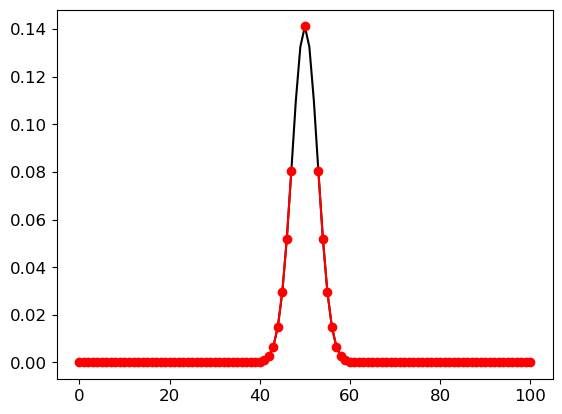

In [ ]:
from dimilibi.helpers import gaussian_filter

p = np.arange(101)
x = np.zeros(101)
x[50] = 1.0
idx_y = np.ones(101, dtype=bool)
idx_y[[48, 49, 51, 52]] = False
y = x[idx_y]
py = p[idx_y]
fx = gaussian_filter(x[None], 2.0, stimulus_positions=p)[0]
fy = gaussian_filter(y[None], 2.0, stimulus_positions=py, full_stimulus_positions=p)[0]
yinx = np.full(101, np.nan)
yinx[idx_y] = fy
plt.close("all")
plt.plot(p, fx, color="k")
plt.plot(p, yinx, color="r", marker="o")
plt.show()

In [ ]:
sessions = sessiondb.iter_sessions(imaging=True)
session = sessions[41]
print(session)
print(session.environments)
hyps = PlaceFieldHyperparameters(smooth_width=6.0)
model = StimSpaceSubspace(
    registry,
    normalize=False,
    hyperparameters=hyps,
    directions_from_placefield_only=True,
)
subspace = model.fit(session, "oasis")
score = model.score(session, subspace, "oasis")

In [5]:
for k, v in score.items():
    print(k, v.shape)

print("\n\n")

safe_root = lambda x: torch.sqrt(torch.clamp(x, min=1e-12))
print(torch.stack((score["variance_placefield_placefield"], safe_root(score["cv_variance_squared_placefield_placefield"])), dim=0).T[:10])

variance_activity torch.Size([2486])
variance_placefields torch.Size([196])
variance_placefield_placefield torch.Size([196])
cv_variance_squared_placefields torch.Size([196])
cv_variance_squared_placefield_placefield torch.Size([196])



tensor([[6277642.5000, 7573000.5000],
        [3881943.2500, 4412958.0000],
        [2564622.7500, 3075834.5000],
        [2108697.5000, 2659590.2500],
        [1393593.6250, 1643250.7500],
        [1018713.6875, 1117730.5000],
        [ 835187.9375, 1450416.8750],
        [ 676867.0625, 1009023.8125],
        [ 535390.9375, 1054031.0000],
        [ 340586.9688,  476583.1562]])


PFP=1.56, PPP=1.31


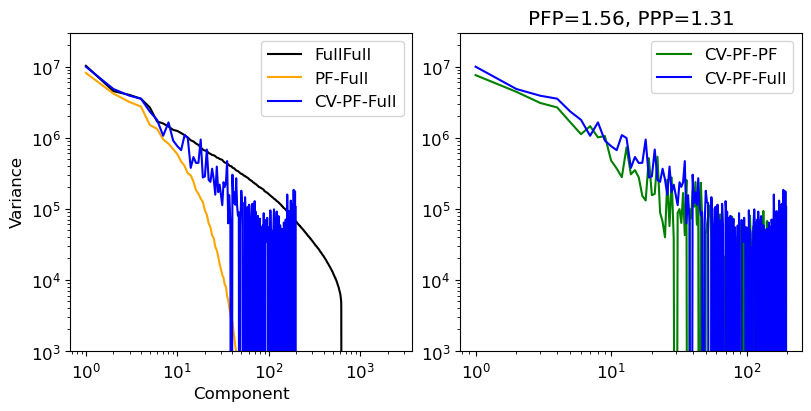

In [31]:
xv = lambda x: np.arange(len(x)) + 1
safe_root = lambda x: torch.sqrt(torch.clamp(x, min=1e-12))
norm = lambda x: x / torch.nansum(x)
plt.close("all")
fig, ax = plt.subplots(1, 2, figsize=(8, 4), layout="constrained")
ax[0].plot(xv(score["variance_activity"]), score["variance_activity"], color="k", label="FullFull")
ax[0].plot(xv(score["variance_placefields"]), score["variance_placefields"], color="orange", label="PF-Full")
ax[0].plot(xv(score["cv_variance_squared_placefields"]), safe_root(score["cv_variance_squared_placefields"]), color="blue", label="CV-PF-Full")
ax[0].set_xlabel("Component")
ax[0].set_ylabel("Variance")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_ylim(1e3, 3e7)
ax[0].legend()

start_idx = 10
end_idx = 20
kws = dict(start_idx=start_idx, end_idx=end_idx)
alpha_pfp = fit_powerlaw_decay(safe_root(score["cv_variance_squared_placefields"]), **kws, ignore_nans=True)[0]
alpha_ppp = fit_powerlaw_decay(safe_root(score["cv_variance_squared_placefield_placefield"]), **kws, ignore_nans=True)[0]
text_alpha = f"PFP={alpha_pfp:.2f}, PPP={alpha_ppp:.2f}"

print(text_alpha)
ax[1].plot(
    xv(score["cv_variance_squared_placefield_placefield"]),
    safe_root(score["cv_variance_squared_placefield_placefield"]),
    color="green",
    label="CV-PF-PF",
)
ax[1].plot(
    xv(score["cv_variance_squared_placefields"]),
    safe_root(score["cv_variance_squared_placefields"]),
    color="blue",
    label="CV-PF-Full",
)

ax[1].set_title(text_alpha)
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_ylim(1e3, 3e7)
ax[1].legend()
plt.show()

In [54]:
spks = session.spks[:, session.idx_rois]
frame_behavior = get_frame_behavior(session)
dist_edges = np.linspace(0, 200, 101)
dist_centers = edge2center(dist_edges)
placefield = get_placefield(spks, frame_behavior, dist_edges, use_fast_sampling=True, session=session)

placefield.shape

subspace.extras.keys()

dict_keys(['pf_pf_kernel', 'pf_full_kernel', 'u_pf_pf', 'u_pf_full', 'idx_keep'])

(300,)


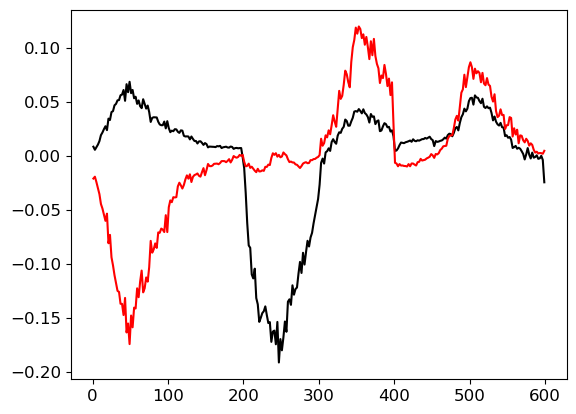

In [56]:
idx0 = 0
idx1 = 1
u_pf_pf = subspace.extras["u_pf_pf"]

plot_centers = np.concatenate([dist_centers + (200 * ienv) for ienv in range(len(session.environments))], axis=0)
print(plot_centers.shape)
plt.close("all")
plt.plot(plot_centers, u_pf_pf[:, idx0], color="k")
plt.plot(plot_centers, u_pf_pf[:, idx1], color="r")
plt.show()

torch.Size([300, 300])
2.3320577e-15


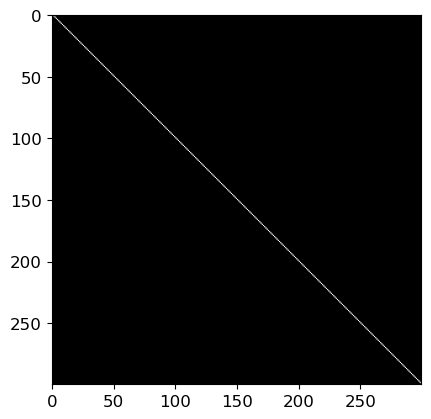

In [ ]:
cross = u_pf_pf.T @ u_pf_pf
print(cross.shape)
values = np.tril(cross, -1)[np.tril(np.ones_like(cross), -1) == 1]
print(np.mean(values**2))
plt.close("all")
plt.imshow(cross**2, cmap="gray")
plt.show()